In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("House_Price_Prediction.csv")

In [3]:
df.head()

,Unnamed: 0,property_type,price,location,city,baths,purpose,bedrooms,Area_in_Marla
0,0,Flat,10000000,G-10,Islamabad,2,For Sale,2,4.0
1,1,Flat,6900000,E-11,Islamabad,3,For Sale,3,5.6
2,2,House,16500000,G-15,Islamabad,6,For Sale,5,8.0
3,3,House,43500000,Bani Gala,Islamabad,4,For Sale,4,40.0
4,4,House,7000000,DHA Defence,Islamabad,3,For Sale,3,8.0


In [4]:
df.shape

(99499, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99499 entries, 0 to 99498
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     99499 non-null  int64  
 1   property_type  99499 non-null  object 
 2   price          99499 non-null  int64  
 3   location       99499 non-null  object 
 4   city           99499 non-null  object 
 5   baths          99499 non-null  int64  
 6   purpose        99499 non-null  object 
 7   bedrooms       99499 non-null  int64  
 8   Area_in_Marla  99499 non-null  float64
dtypes: float64(1), int64(4), object(4)
memory usage: 6.8+ MB


In [7]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [8]:
df.isnull().sum()

property_type    0
price            0
location         0
city             0
baths            0
purpose          0
bedrooms         0
Area_in_Marla    0
dtype: int64

No significant missing values were found in the dataset. The dataset is suitable for further analysis and model building.

In [10]:
df.duplicated().sum()

np.int64(37858)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.describe()

,price,baths,bedrooms,Area_in_Marla
count,6.164100e+04,61641.000000,61641.000000,61641.000000
mean,9.610426e+06,3.453383,3.334307,8.591924
std,1.030790e+07,1.483044,1.303504,8.145067
min,1.550000e+04,1.000000,0.000000,0.000000
25%,1.350000e+05,2.000000,2.000000,4.400000
50%,6.600000e+06,3.000000,3.000000,6.000000
75%,1.480000e+07,4.000000,4.000000,10.000000
max,4.490000e+07,7.000000,6.000000,194.000000


The dataset contains house properties with varying prices, bedroom counts, bathroom counts, and area sizes. Significant variation in price suggests a diverse housing market.

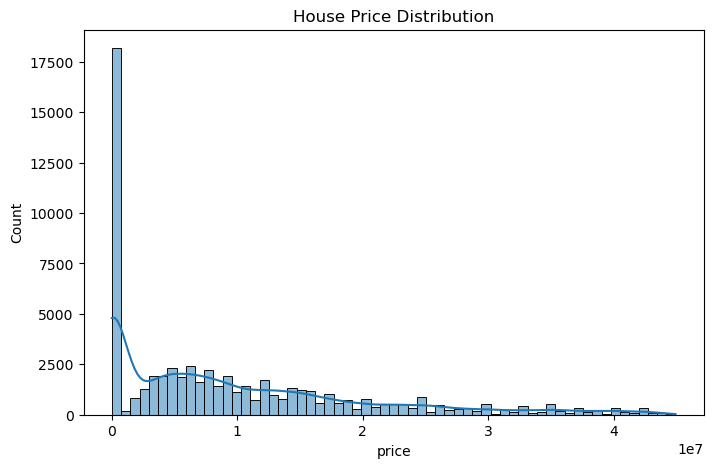

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], kde=True)
plt.title("House Price Distribution")
plt.show()

Most houses are concentrated in the lower to medium price range, while a small number of luxury properties create a right-skewed distribution.

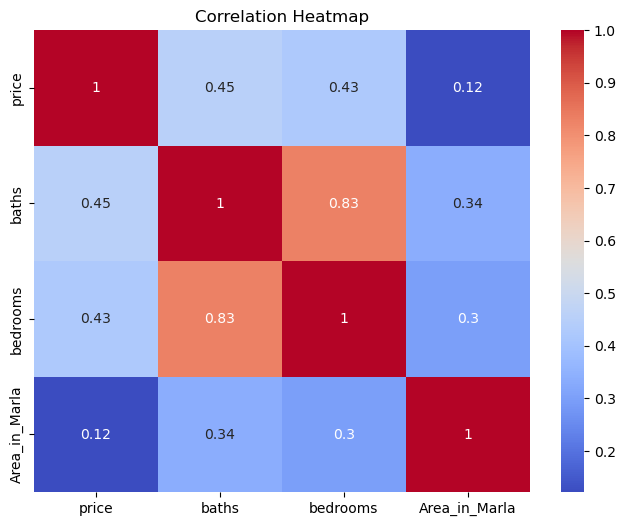

In [14]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

Area, bedrooms, and bathrooms show positive correlations with house price, indicating that larger properties generally have higher prices.

Selected features include:

- Area_in_Marla
- Bedrooms
- Baths
- Property Type
- Location
- City

These features directly influence house prices because larger houses with more rooms and desirable locations typically command higher market values.

In [15]:
X = df.drop("price", axis=1)

y = df["price"]

In [16]:
cat_cols = X.select_dtypes(include="object").columns

cat_cols

Index(['property_type', 'location', 'city', 'purpose'], dtype='object')

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_cols
        )
    ],
    remainder="passthrough"
)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [19]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
y_pred = model.predict(X_test)

In [21]:
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MSE : 36183948738341.49
RMSE : 6015309.529720103
R2 Score : 0.6533362823415249


The R² score indicates how well the model explains the variation in house prices. A higher R² value indicates better predictive performance.

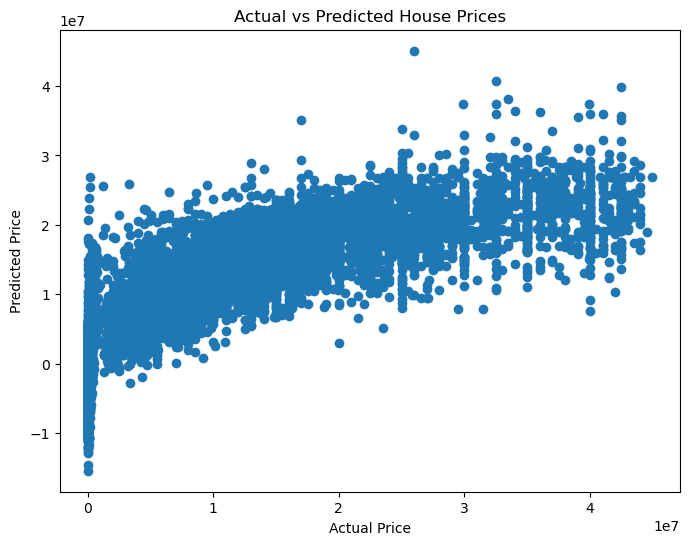

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

Most predicted values lie close to the diagonal trend, indicating that the model performs reasonably well.

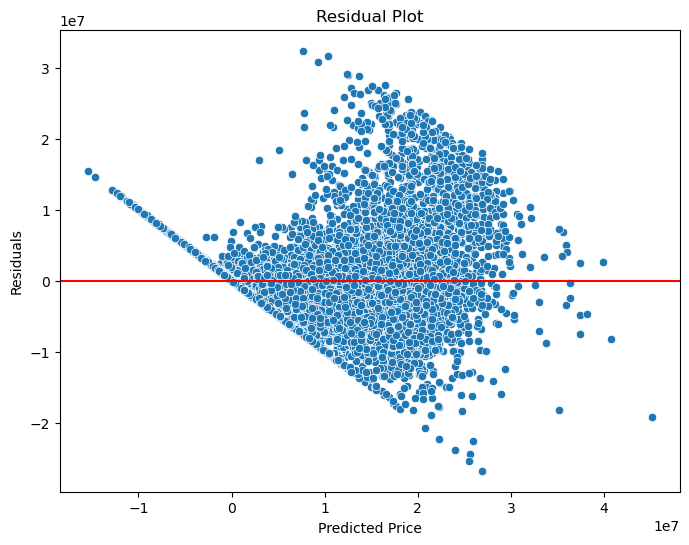

In [23]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    y=0,
    color="red"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

Residuals are randomly distributed around zero, suggesting that the linear regression assumptions are reasonably satisfied.

In [24]:
ridge = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge())
])

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

print(
    r2_score(y_test, ridge_pred)
)

0.6546617034611126


In [26]:
lasso = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Lasso())
])

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

print(
    r2_score(y_test, lasso_pred)
)

0.6532727321151723


C:\Users\Rudra\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.516e+17, tolerance: 5.262e+14
  model = cd_fast.sparse_enet_coordinate_descent(


## Conclusion

- Cleaned and prepared the housing dataset.
- Performed exploratory data analysis.
- Encoded categorical features using One-Hot Encoding.
- Trained a Linear Regression model for house price prediction.
- Evaluated the model using MSE, RMSE, and R² Score.
- Visualized predictions and residuals.
- Compared Linear Regression with Ridge and Lasso Regression models.
- The model successfully predicts house prices using property characteristics and location information.